In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3.

In [2]:
from ultralytics import YOLO
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


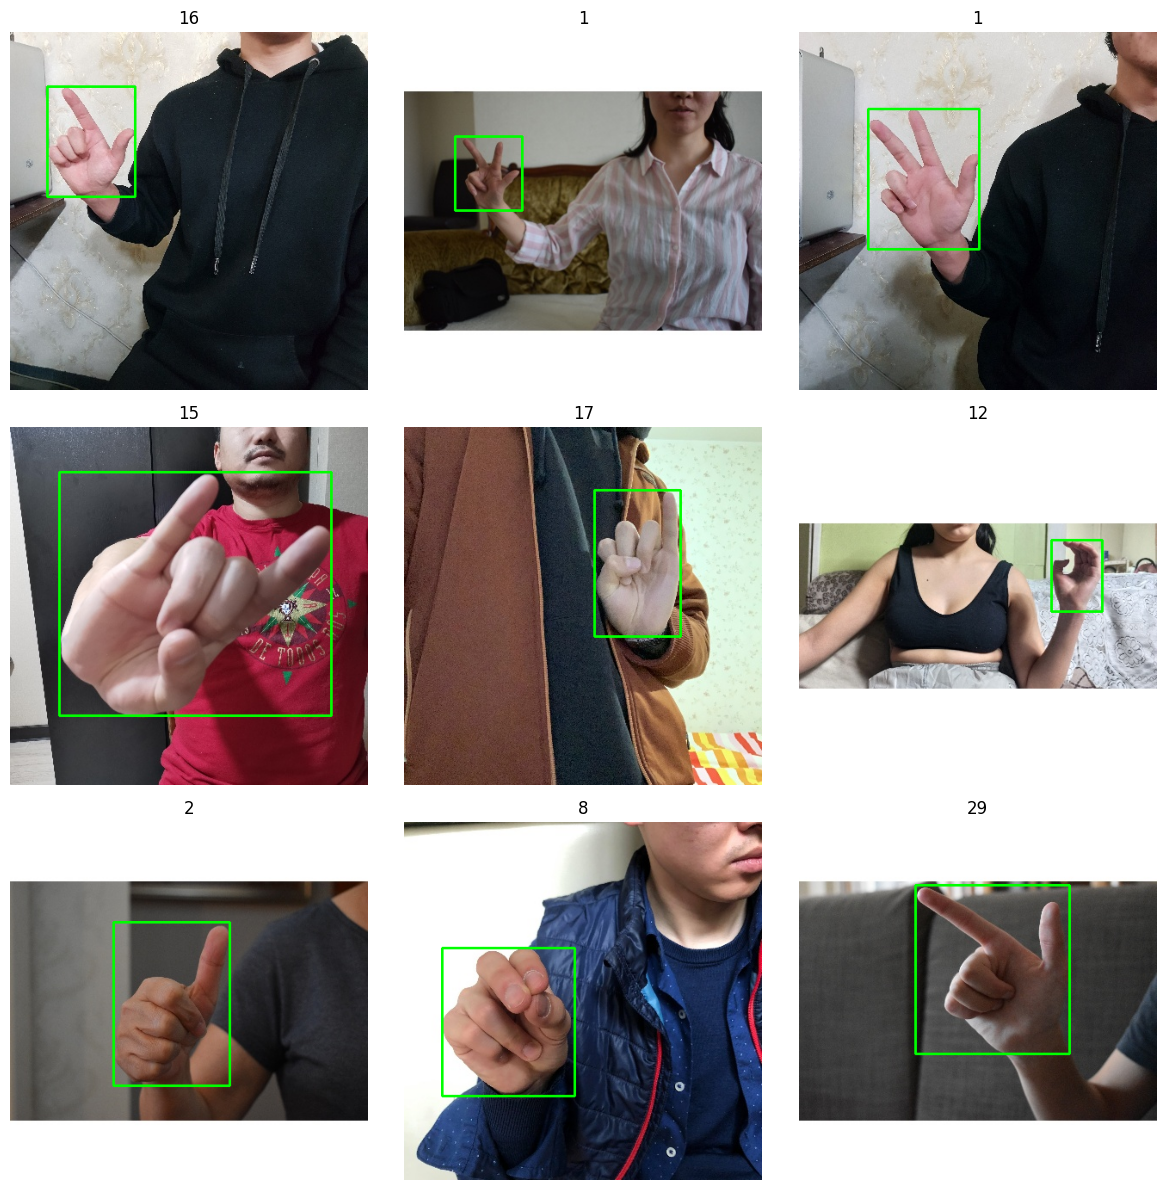

In [3]:
def read_labels(label_path):
    with open(label_path, 'r') as file:
        lines = file.readlines()
        labels = [line.strip().split() for line in lines]
    return labels

def draw_boxes(image, labels):
    for label in labels:
        class_id = int(label[0])
        x, y, w, h = map(float, label[1:])
        image_height, image_width, _ = image.shape
        x1 = int((x - w / 2) * image_width)
        y1 = int((y - h / 2) * image_height)
        x2 = int((x + w / 2) * image_width)
        y2 = int((y + h / 2) * image_height)
        color = (0, 255, 0)  # Green
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
    return image

data_dir = '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/train'

image_files = [file for file in os.listdir(os.path.join(data_dir, 'images')) if file.endswith('.jpg')]

random.shuffle(image_files)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, image_file in zip(axes.ravel(), image_files[:9]):
    image_path = os.path.join(data_dir, 'images', image_file)
    label_path = os.path.join(data_dir, 'labels', os.path.splitext(image_file)[0] + '.txt')

    # Read image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read labels
    labels = read_labels(label_path)

    # Draw bounding boxes on the image
    image_with_boxes = draw_boxes(image_rgb, labels)

    # Display image with bounding boxes and set the labels as titles
    ax.imshow(image_with_boxes)
    ax.set_title(str(labels[0][0]))
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
model = YOLO('yolo11n.pt')

100%|██████████| 5.35M/5.35M [00:00<00:00, 75.1MB/s]


In [5]:
history = model.train(data="/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/sign.yaml", epochs=150, imgsz=416,
                    patience = 20, batch = 32,  
                    project="/kaggle/working/ASL", optimizer = 'Adam', momentum = 0.9,
                    cos_lr=True ,seed = 42, plots = True , close_mosaic = 0, lr0 = 0.001)

Ultralytics 8.3.153 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/sign.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.9, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, pat

100%|██████████| 22.2M/22.2M [00:00<00:00, 175MB/s]


Overriding model.yaml nc=80 with nc=32

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytic

train: Scanning /kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/train/labels... 9955 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9955/9955 [00:31<00:00, 313.89it/s]


WARNING ⚠️ train: Cache directory /kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.8±4.6 MB/s, size: 47.9 KB)


...

    150/150      2.51G     0.5476     0.5421     0.9409          5        416: 100%|██████████| 312/312 [01:06<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:17<00:00,  3.79it/s]

                   all       4247       4252      0.971      0.967      0.988      0.842



150 epochs completed in 3.469 hours.
Optimizer stripped from /kaggle/working/ASL/train/weights/last.pt, 5.5MB
Optimizer stripped from /kaggle/working/ASL/train/weights/best.pt, 5.5MB

Validating /kaggle/working/ASL/train/weights/best.pt...
Ultralytics 8.3.153 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,588,392 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:20<00:00,  3.23it/s]


                   all       4247       4252      0.971      0.966      0.988      0.841
                     ع        133        133      0.993      0.992      0.995      0.834
                    ال        135        136      0.985       0.99      0.993      0.926
                     أ        134        136          1      0.984      0.995      0.904
                     ب        135        137      0.985      0.977      0.992      0.901
                     د        111        111      0.971      0.911       0.97      0.806
                     ظ        135        135      0.961      0.978      0.992      0.867
                     ض        130        130      0.962      0.974      0.989      0.853
                     ف        135        135      0.911      0.906       0.96      0.811
                     ق        134        134      0.964      0.948      0.987      0.833
                     غ        135        135          1      0.995      0.995      0.854
                     

In [6]:
# Load the trained model
model = YOLO('/kaggle/working/ASL/train/weights/best.pt')

# Evaluate on the validation set
metrics = model.val()  # Computes mAP50, mAP50-95, precision, recall, etc.
print(f"mAP50-95: {metrics.box.map}")    # map Mean AP at IoU thresholds from 0.5 to 0.95 for all classes.
print(f"mAP50: {metrics.box.map50}")  # mAP50 Mean AP at IoU threshold of 0.5 for all classes.
print(f"Precision (mP): {metrics.box.mp}")  # Precision
print(f"Recall (mR): {metrics.box.mr}")     # Recall

Ultralytics 8.3.153 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,588,392 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 87.6±52.5 MB/s, size: 48.8 KB)


val: Scanning /kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/labels... 4247 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4247/4247 [00:06<00:00, 694.94it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 266/266 [00:20<00:00, 12.79it/s]


                   all       4247       4252      0.971      0.967      0.988      0.842
                     ع        133        133      0.993      0.992      0.995      0.832
                    ال        135        136      0.985       0.99      0.993      0.924
                     أ        134        136          1      0.984      0.995      0.903
                     ب        135        137      0.985      0.977      0.992      0.902
                     د        111        111      0.971      0.911       0.97      0.805
                     ظ        135        135      0.961      0.978      0.992      0.867
                     ض        130        130      0.962      0.974      0.989      0.854
                     ف        135        135      0.911      0.906       0.96       0.81
                     ق        134        134      0.962      0.949      0.987       0.83
                     غ        135        135          1      0.995      0.995      0.852
                     

In [7]:
test_images_dir = '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images'
test_images = [os.path.join(test_images_dir, image) for image in os.listdir(test_images_dir)]

test_samples = np.random.choice(test_images, 10, replace=False)

print(test_samples)

['/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1034_19_M_al_7.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1051_25_M_toot_8.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1011_37_F_haa_6.jpg'
 '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/23_19_M_ghain_7.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/14_19_F_ya_6.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1003_19_F_meem_4.jpg'
 '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1051_25_M_dhad_0.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1005_16_F_jeem_4.jpg' '/kaggle/input/arabic-sign-language-data/Arabic Sign Language Data/ASL/valid/images/1035_18_F_saad_6.jpg'
 '/kaggle/input/arabic-sign-language-data/Arabic Si

In [8]:
results = model([test_samples[0], test_samples[1], test_samples[2], test_samples[3], test_samples[4], test_samples[5], test_samples[6], test_samples[7], test_samples[8], test_samples[9]])

results_dir = "results_tries"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    
i = 0
for result in results:
    boxes = result.boxes  
    masks = result.masks  
    keypoints = result.keypoints  
    probs = result.probs 
    
    # Save image
    filename = os.path.join(results_dir, f"result_{i}.jpg")
    result.save(filename=filename)
    # result.show() # Uncomment to display image
    i+=1


0: 416x416 1 ال, 5.4ms
1: 416x416 1 ة, 5.4ms
2: 416x416 1 ه, 5.4ms
3: 416x416 1 غ, 5.4ms
4: 416x416 1 ئ, 5.4ms
5: 416x416 1 م, 5.4ms
6: 416x416 1 ض, 5.4ms
7: 416x416 1 ح, 1 ج, 5.4ms
8: 416x416 1 ص, 5.4ms
9: 416x416 1 ة, 5.4ms
Speed: 0.7ms preprocess, 5.4ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 416)


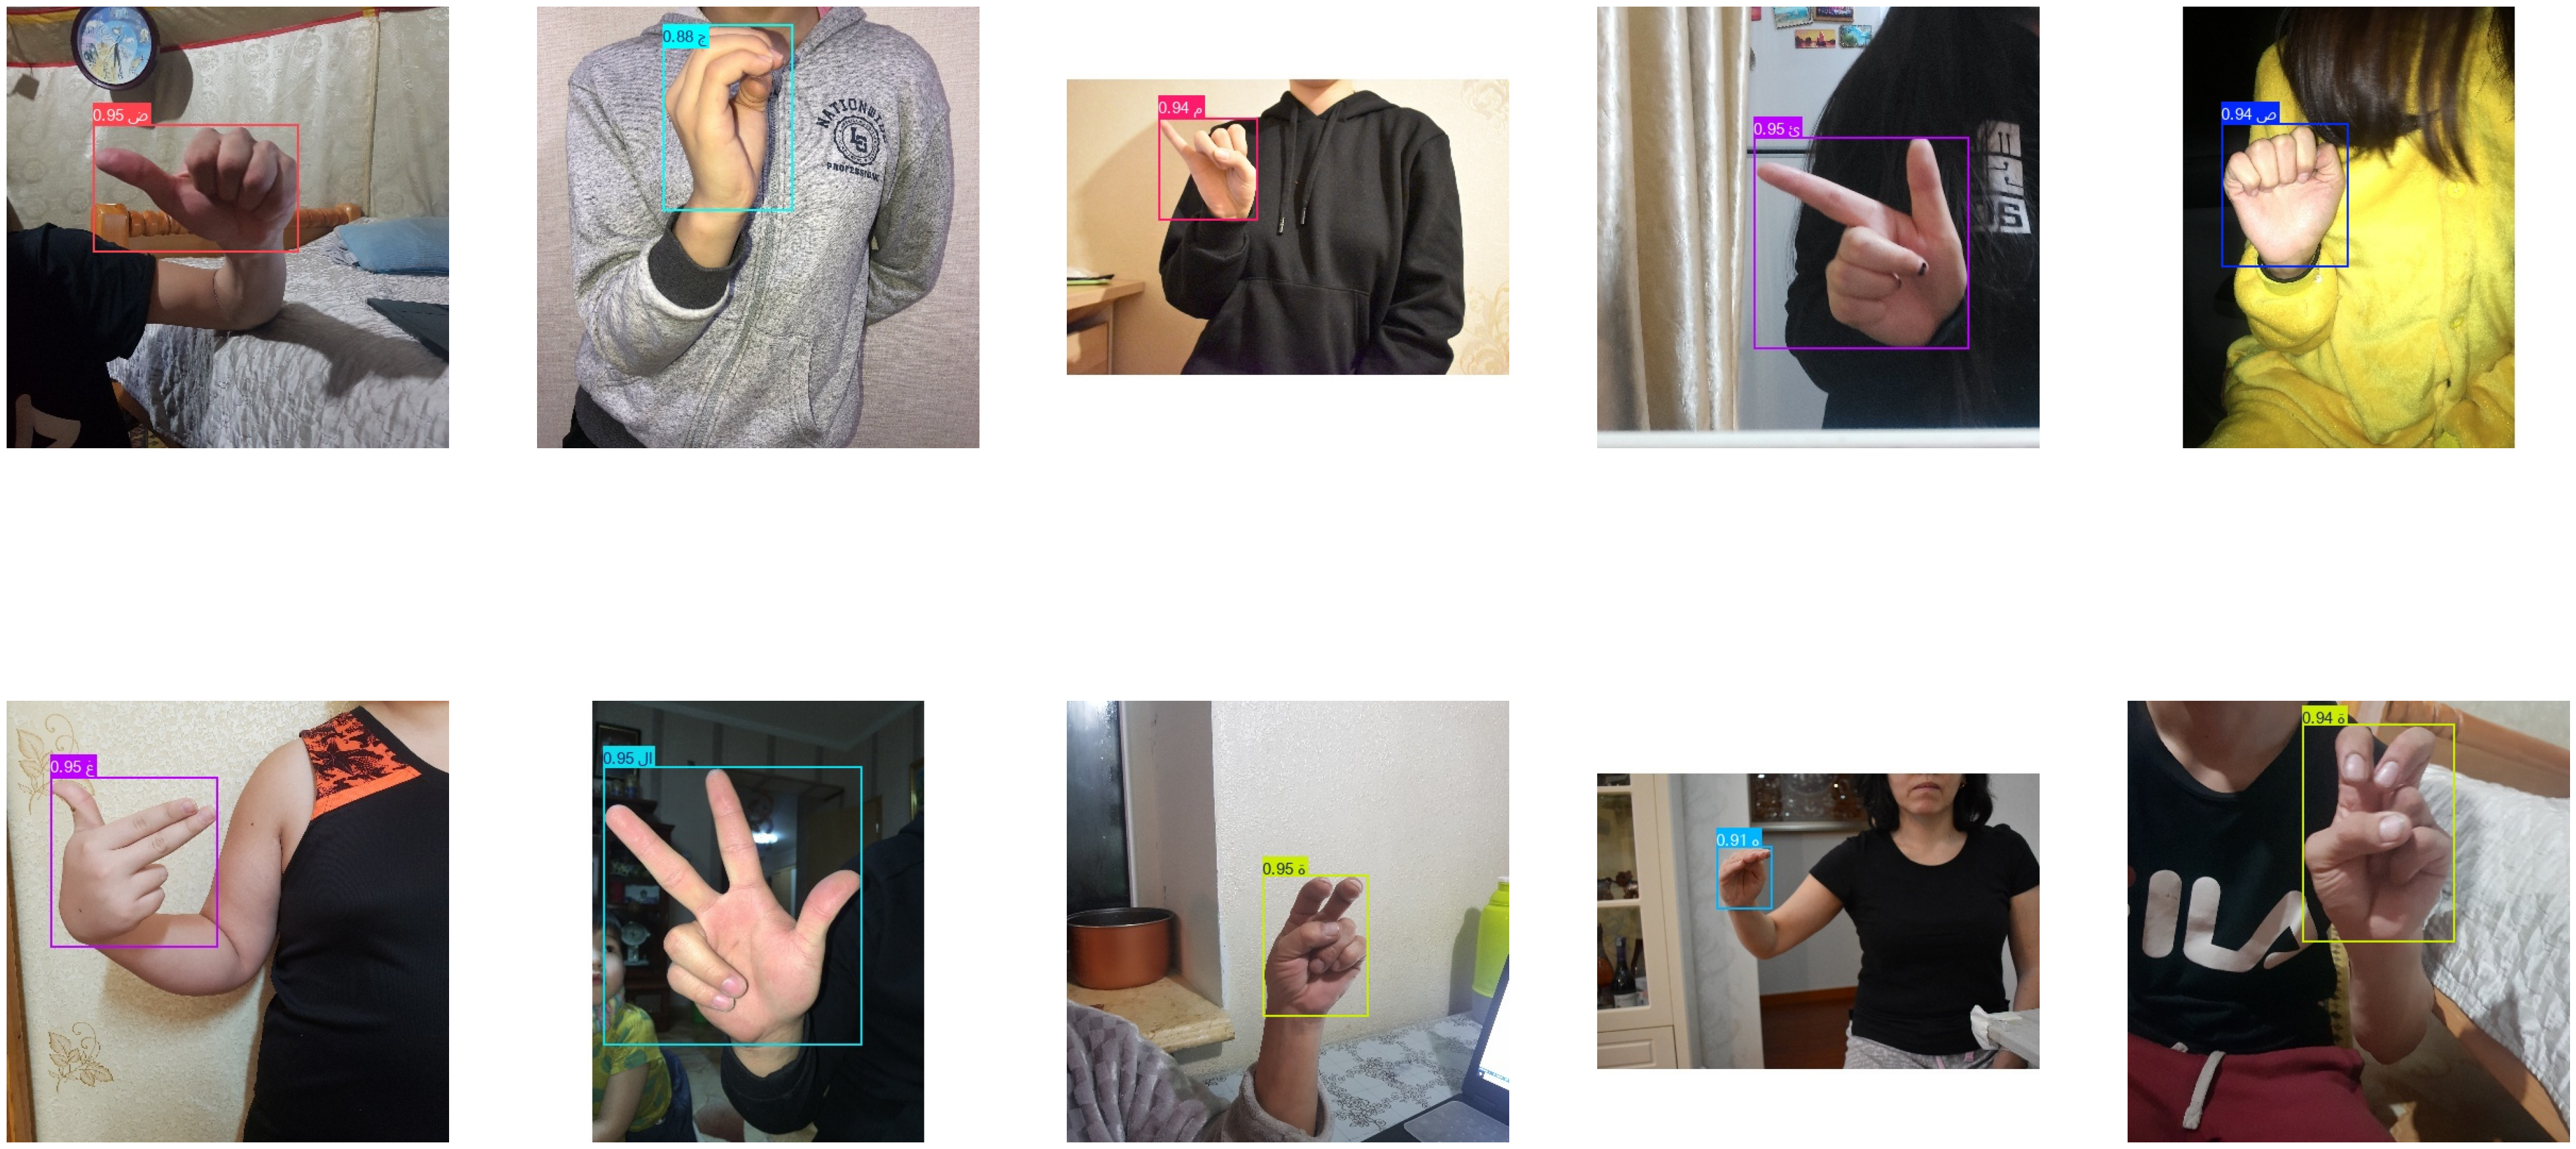

In [9]:
directory = "results_tries"

images = []
for filename in os.listdir(directory):
    if filename.endswith(".jpg"):
        img = plt.imread(os.path.join(directory, filename))
        images.append(img)

fig, axs = plt.subplots(2, 5, figsize=(50, 25))
for i in range(10):
    axs[i//5, i%5].imshow(images[i])
    axs[i//5, i%5].axis('off')

plt.show()